# Exploratory Data Analysis (EDA) - LIAR Dataset

## Analyse complète d'un corpus NLP pour le Fact-Checking

**Objectif** : Réaliser une exploration des données avant toute modélisation
- Comprendre la structure et la qualité des données
- Analyser les caractéristiques des textes
- Évaluer l'équilibre des classes
- Identifier les besoins en preprocessing

**Dataset** : LIAR Dataset (train, validation, test)
- Format : TSV (textes et métadonnées)

# SECTION 1 : CHARGEMENT ET COMPRÉHENSION DES DONNÉES

In [5]:
# ============================================================================
# SECTION 1 : CHARGEMENT ET COMPRÉHENSION DES DONNÉES
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import warnings
import re
import os
from collections import Counter
import emoji

warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Télécharger les ressources NLTK nécessaires
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Définir le chemin de base
BASE_PATH = r"d:\Fify\Epitech\Module de spé 3\liar_dataset-master"
DATA_PATH = os.path.join(BASE_PATH, "data")

print("=" * 80)
print("CHARGEMENT DES DONNÉES")
print("=" * 80)

CHARGEMENT DES DONNÉES


In [6]:
# Charger les fichiers TSV (textes et métadonnées)
tsv_columns = ['id', 'label', 'text', 'category', 'speaker', 'position', 'state', 'party', 
               'barely_true_count', 'false_count', 'half_true_count', 'mostly_true_count', 
               'true_count', 'context']

# Charger les datasets TSV depuis le dossier data/
df_train_tsv = pd.read_csv(os.path.join(DATA_PATH, 'train.tsv'), sep='\t', names=tsv_columns, 
                           header=None, quoting=3, encoding='utf-8')
df_valid_tsv = pd.read_csv(os.path.join(DATA_PATH, 'valid.tsv'), sep='\t', names=tsv_columns, 
                           header=None, quoting=3, encoding='utf-8')
df_test_tsv = pd.read_csv(os.path.join(DATA_PATH, 'test.tsv'), sep='\t', names=tsv_columns, 
                          header=None, quoting=3, encoding='utf-8')

print(f"✓ Train TSV chargé : {df_train_tsv.shape}")
print(f"✓ Validation TSV chargé : {df_valid_tsv.shape}")
print(f"✓ Test TSV chargé : {df_test_tsv.shape}")

✓ Train TSV chargé : (10269, 14)
✓ Validation TSV chargé : (1284, 14)
✓ Test TSV chargé : (1283, 14)


In [7]:
# Afficher les premières lignes de chaque dataset
print("\n" + "=" * 80)
print("APERÇU DES DONNÉES - TRAIN SET (TSV)")
print("=" * 80)
print(df_train_tsv.head())

print("\n" + "=" * 80)
print("INFORMATIONS STRUCTURELLES")
print("=" * 80)

# Résumé des dimensions
summary_data = {
    'Dataset': ['Train', 'Validation', 'Test'],
    'Nombre de lignes': [len(df_train_tsv), len(df_valid_tsv), len(df_test_tsv)],
    'Nombre de colonnes': [len(df_train_tsv.columns), len(df_valid_tsv.columns), len(df_test_tsv.columns)]
}
print(pd.DataFrame(summary_data).to_string(index=False))


APERÇU DES DONNÉES - TRAIN SET (TSV)
           id        label                                               text  \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                             category         speaker              position  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   



# SECTION 2 : ANALYSE DE LA QUALITÉ DES DONNÉES

## 2.1 Valeurs manquantes

In [8]:
print("=" * 80)
print("ANALYSE DE LA QUALITÉ DES DONNÉES")
print("=" * 80)

# Vérifier les valeurs manquantes ET les types de données
def analyze_data_quality(df, dataset_name):
    print(f"\n{dataset_name} - Aperçu général:")
    print(f"  - Nombre de lignes : {len(df)}")
    print(f"  - Nombre de colonnes : {len(df.columns)}")
    
    print(f"\n{dataset_name} - Types de données:")
    for col, dtype in df.dtypes.items():
        print(f"  - {col}: {dtype}")
    
    print(f"\n{dataset_name} - Valeurs manquantes ET statistiques par colonne:")
    
    quality_stats = []
    for col in df.columns:
        missing_count = df[col].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100
        
        # Compter les valeurs uniques
        unique_count = df[col].nunique()
        
        # Statistiques selon le type de données
        stats = {
            'Colonne': col,
            'Type': str(df[col].dtype),
            'Valeurs manquantes': missing_count,
            'Pourcentage (%)': f"{missing_pct:.2f}",
            'Valeurs uniques': unique_count
        }
        quality_stats.append(stats)
    
    quality_df = pd.DataFrame(quality_stats)
    print(quality_df.to_string(index=False))
    
    # Afficher les doublons
    print(f"\n{dataset_name} - Doublons:")
    total_duplicates = df.duplicated().sum()
    print(f"  - Doublons complets (toutes colonnes) : {total_duplicates}")
    
    duplicates_text = df.duplicated(subset=['text']).sum()
    print(f"  - Doublons sur la colonne 'text' : {duplicates_text}")
    
    # Afficher les statistiques descriptives pour les colonnes numériques
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"\n{dataset_name} - Statistiques descriptives (colonnes numériques):")
        print(df[numeric_cols].describe().to_string())
    
    return quality_df

print("\n" + "-" * 80)
print("ANALYSE COMPLÈTE - FICHIERS TSV")
print("-" * 80)

quality_train = analyze_data_quality(df_train_tsv, "Train")
quality_valid = analyze_data_quality(df_valid_tsv, "Validation")
quality_test = analyze_data_quality(df_test_tsv, "Test")

ANALYSE DE LA QUALITÉ DES DONNÉES

--------------------------------------------------------------------------------
ANALYSE COMPLÈTE - FICHIERS TSV
--------------------------------------------------------------------------------

Train - Aperçu général:
  - Nombre de lignes : 10269
  - Nombre de colonnes : 14

Train - Types de données:
  - id: object
  - label: object
  - text: object
  - category: object
  - speaker: object
  - position: object
  - state: object
  - party: object
  - barely_true_count: int64
  - false_count: int64
  - half_true_count: int64
  - mostly_true_count: int64
  - true_count: int64
  - context: object

Train - Valeurs manquantes ET statistiques par colonne:
          Colonne   Type  Valeurs manquantes Pourcentage (%)  Valeurs uniques
               id object                   0            0.00            10269
            label object                   0            0.00                6
             text object                   0            0.00            1

## 2.2 Doublons et incohérences

In [ ]:
print("\n" + "-" * 80)
print("ANALYSE DÉTAILLÉE DES INCOHÉRENCES")
print("-" * 80)

def check_data_inconsistencies(df, dataset_name):
    print(f"\n{dataset_name}:")
    
    # 1. Textes vides ou très courts
    empty_texts = (df['text'].fillna("").str.len() == 0).sum()
    very_short = (df['text'].fillna("").str.len() < 5).sum()
    print(f"  - Textes vides : {empty_texts}")
    print(f"  - Textes très courts (< 5 caractères) : {very_short}")
    
    # 2. Labels non valides
    valid_labels = ['   ]
    invalid_labels = df[~df['label'].isin(valid_labels)]
    print(f"  - Labels valides trouvés : {sorted(df['label'].unique().tolist())}")
    print(f"  - Labels non valides : {len(invalid_labels)}")
    if len(invalid_labels) > 0:
        print(f"    Labels uniques non valides : {invalid_labels['label'].unique()}")
    
    # 3. Vérifier les colonnes avec beaucoup de valeurs NULL
    null_columns = df.isnull().sum()
    null_columns = null_columns[null_columns > 0].sort_values(ascending=False)
    if len(null_columns) > 0:
        print(f"\n  - Colonnes avec valeurs NULL:")
        for col, count in null_columns.items():
            pct = (count / len(df)) * 100
            print(f"    • {col}: {count} ({pct:.2f}%)")
    else:
        print(f"  - ✓ Aucune colonne avec valeurs NULL")
    
    # 4. Vérifier les colonnes numériques pour valeurs négatives ou aberrantes
    numeric_cols = ['barely_true_count', 'false_count', 'half_true_count', 'mostly_true_count', 'true_count']
    print(f"\n  - Vérification des colonnes de votes (devraient être >= 0):")
    for col in numeric_cols:
        if col in df.columns:
            negative_count = (df[col] < 0).sum()
            print(f"    • {col}: {negative_count} valeurs négatives")
    
    # 5. Somme des votes
    if all(col in df.columns for col in numeric_cols):
        df_temp = df.copy()
        df_temp['vote_sum'] = (df_temp['barely_true_count'] + df_temp['false_count'] + 
                               df_temp['half_true_count'] + df_temp['mostly_true_count'] + 
                               df_temp['true_count'])
        zero_votes = (df_temp['vote_sum'] == 0).sum()
        print(f"  - Entrées avec somme de votes = 0 : {zero_votes}")
        print(f"    Moyenne des votes par entrée: {df_temp['vote_sum'].mean():.2f}")
        print(f"    Médiane des votes par entrée: {df_temp['vote_sum'].median():.2f}")
    
    # 6. Vérifier les colonnes texte pour caractères spéciaux
    text_cols = ['speaker', 'party', 'state', 'category']
    print(f"\n  - Vérification des colonnes texte :")
    for col in text_cols:
        if col in df.columns:
            unique_vals = df[col].nunique()
            sample_nulls = df[col].isnull().sum()
            print(f"    • {col}: {unique_vals} valeurs uniques, {sample_nulls} NULL")

check_data_inconsistencies(df_train_tsv, "Train")
check_data_inconsistencies(df_valid_tsv, "Validation")
check_data_inconsistencies(df_test_tsv, "Test")


--------------------------------------------------------------------------------
ANALYSE DÉTAILLÉE DES INCOHÉRENCES
--------------------------------------------------------------------------------

Train:
  - Textes vides : 0
  - Textes très courts (< 5 caractères) : 0
  - Labels valides trouvés : ['barely-true', 'false', 'half-true', 'mostly-true', 'pants-fire', 'true']
  - Labels non valides : 0

  - Colonnes avec valeurs NULL:
    • position: 2902 (28.26%)
    • state: 2211 (21.53%)
    • context: 100 (0.97%)

  - Vérification des colonnes de votes (devraient être >= 0):
    • barely_true_count: 0 valeurs négatives
    • false_count: 0 valeurs négatives
    • half_true_count: 0 valeurs négatives
    • mostly_true_count: 0 valeurs négatives
    • true_count: 0 valeurs négatives
  - Entrées avec somme de votes = 0 : 340
    Moyenne des votes par entrée: 64.76
    Médiane des votes par entrée: 11.00

  - Vérification des colonnes texte :
    • speaker: 2916 valeurs uniques, 0 NULL
   

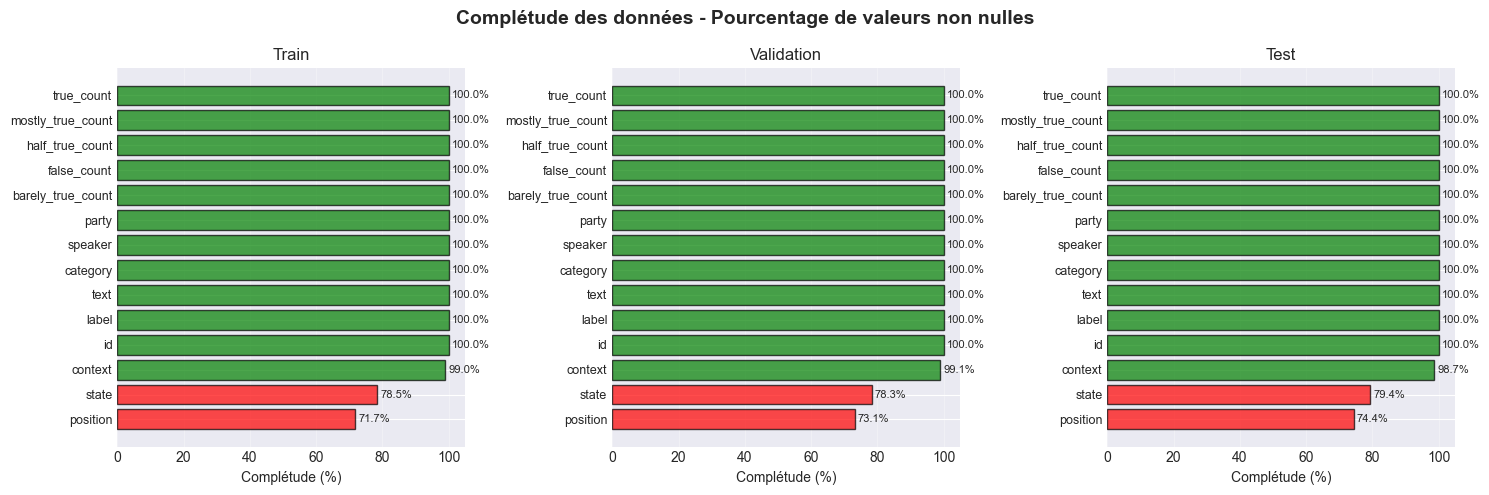

✓ Analyse de qualité complète et visualisation générées


In [10]:
# Visualisation de la complétude des données
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Complétude des données - Pourcentage de valeurs non nulles', fontsize=14, fontweight='bold')

datasets = [
    (df_train_tsv, 'Train', axes[0]),
    (df_valid_tsv, 'Validation', axes[1]),
    (df_test_tsv, 'Test', axes[2])
]

for df, name, ax in datasets:
    completeness = ((df.count() / len(df)) * 100).sort_values(ascending=True)
    
    colors = ['green' if x >= 95 else 'orange' if x >= 80 else 'red' for x in completeness.values]
    ax.barh(range(len(completeness)), completeness.values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(completeness)))
    ax.set_yticklabels(completeness.index, fontsize=9)
    ax.set_xlabel('Complétude (%)')
    ax.set_title(f'{name}')
    ax.set_xlim([0, 105])
    ax.grid(axis='x', alpha=0.3)
    
    # Ajouter les pourcentages
    for i, v in enumerate(completeness.values):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Analyse de qualité complète et visualisation générées")

In [11]:
print("\n" + "-" * 80)
print("ANALYSE DES MÉTADONNÉES CATÉGORIQUES")
print("-" * 80)

def analyze_categorical_features(df, dataset_name):
    """Analyser les features catégoriques"""
    print(f"\n{dataset_name}:")
    
    categorical_cols = ['category', 'party', 'speaker', 'state', 'position']
    
    for col in categorical_cols:
        if col in df.columns:
            print(f"\n  ✓ {col.upper()}:")
            
            # Nombre total unique
            unique_count = df[col].nunique()
            null_count = df[col].isnull().sum()
            
            print(f"    - Nombre total unique : {unique_count}")
            print(f"    - Valeurs NULL : {null_count}")
            
            # Top 10
            top_n = df[col].value_counts().head(10)
            print(f"    - Top 10 :")
            for i, (val, count) in enumerate(top_n.items(), 1):
                pct = (count / len(df)) * 100
                print(f"      {i}. {val}: {count} ({pct:.2f}%)")

analyze_categorical_features(df_train_tsv, "Train")
analyze_categorical_features(df_valid_tsv, "Validation")
analyze_categorical_features(df_test_tsv, "Test")


--------------------------------------------------------------------------------
ANALYSE DES MÉTADONNÉES CATÉGORIQUES
--------------------------------------------------------------------------------

Train:

  ✓ CATEGORY:
    - Nombre total unique : 3836
    - Valeurs NULL : 0
    - Top 10 :
      1. health-care: 382 (3.72%)
      2. taxes: 308 (3.00%)
      3. immigration: 253 (2.46%)
      4. elections: 253 (2.46%)
      5. education: 238 (2.32%)
      6. candidates-biography: 190 (1.85%)
      7. economy: 138 (1.34%)
      8. guns: 130 (1.27%)
      9. economy,jobs: 125 (1.22%)
      10. federal-budget: 122 (1.19%)

  ✓ PARTY:
    - Nombre total unique : 23
    - Valeurs NULL : 0
    - Top 10 :
      1. republican: 4510 (43.92%)
      2. democrat: 3345 (32.57%)
      3. none: 1746 (17.00%)
      4. organization: 220 (2.14%)
      5. independent: 149 (1.45%)
      6. newsmaker: 58 (0.56%)
      7. activist: 40 (0.39%)
      8. libertarian: 40 (0.39%)
      9. journalist: 38 (0.37%)


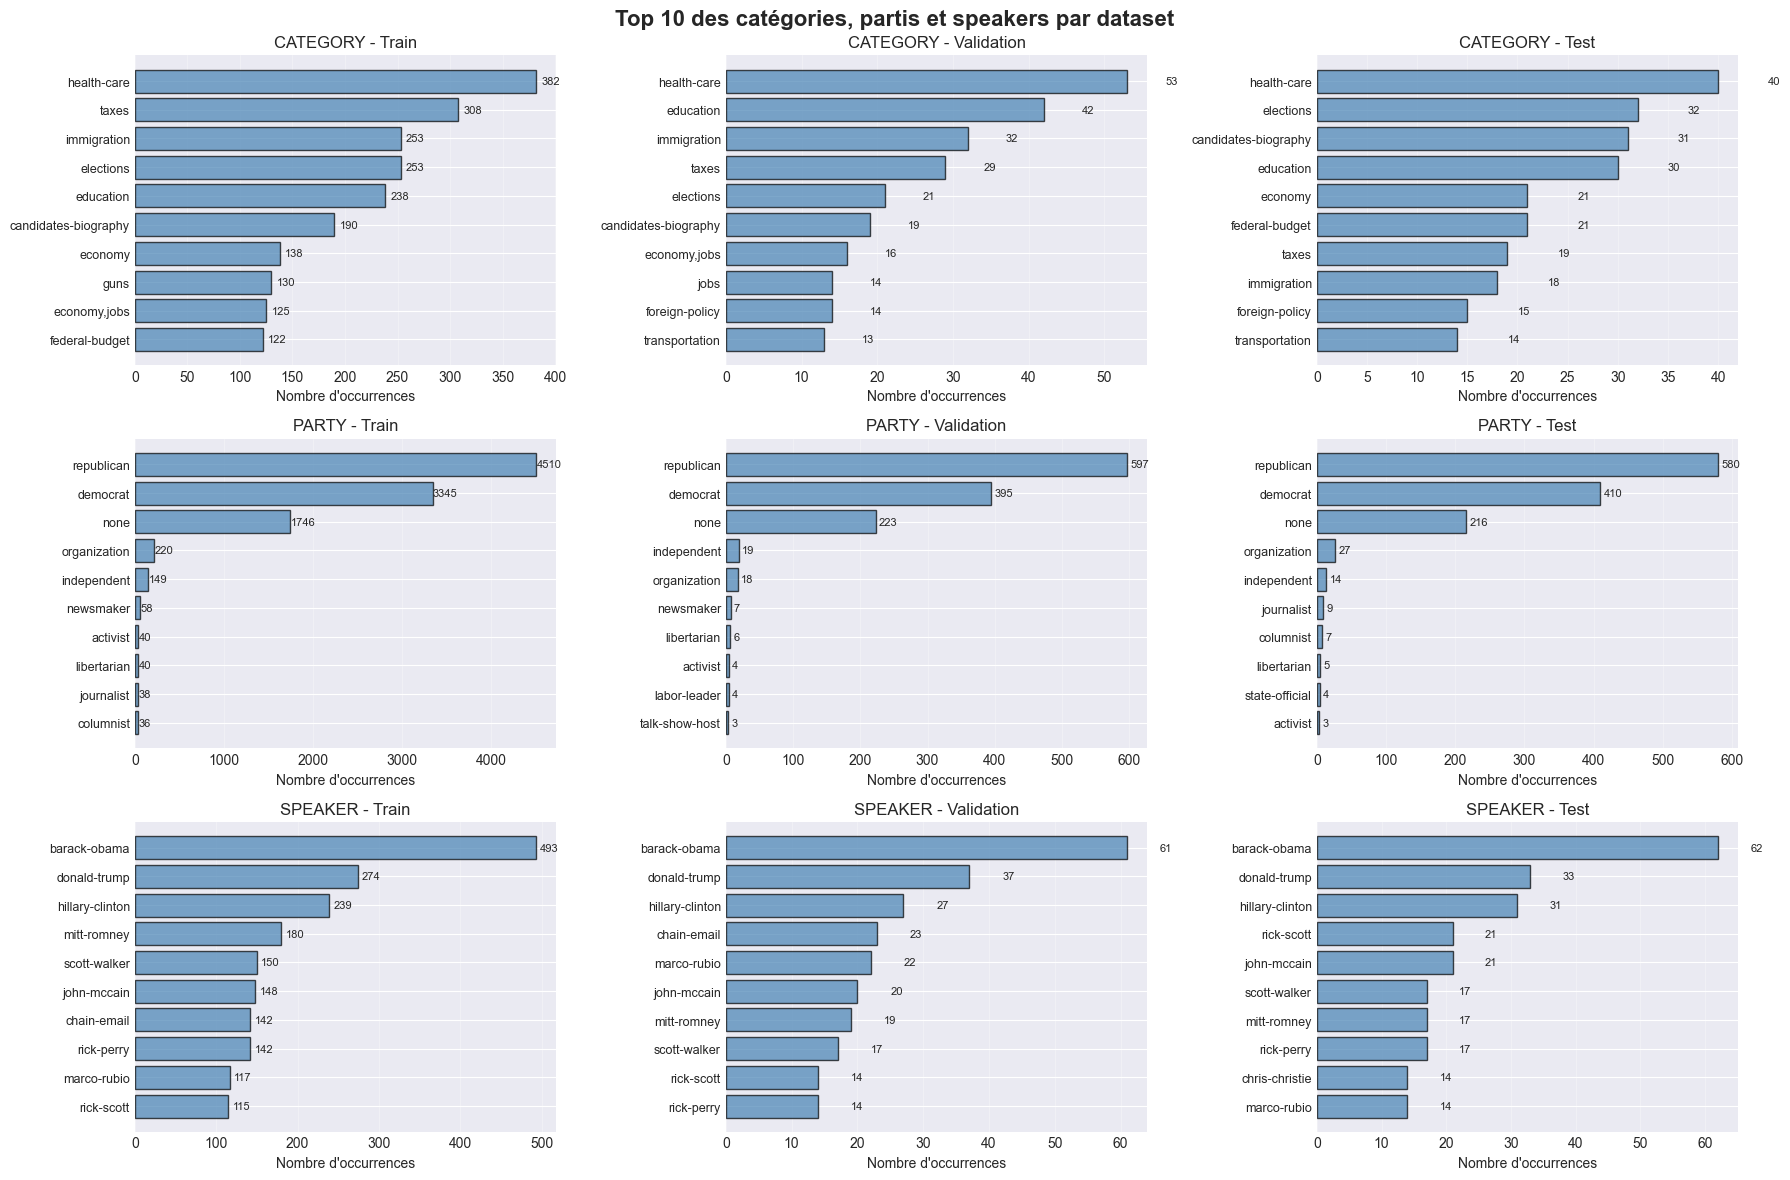

✓ Visualisations des catégories, partis et speakers générées


In [12]:
# Visualisation des Top 10 pour Category, Party et Speaker
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Top 10 des catégories, partis et speakers par dataset', fontsize=16, fontweight='bold')

# Données à analyser
categorical_features = ['category', 'party', 'speaker']
datasets = [
    (df_train_tsv, 'Train'),
    (df_valid_tsv, 'Validation'),
    (df_test_tsv, 'Test')
]

# Boucle pour créer les graphiques
for row, (feature) in enumerate(categorical_features):
    for col, (df, ds_name) in enumerate(datasets):
        ax = axes[row, col]
        
        if feature in df.columns:
            # Obtenir le top 10
            top_data = df[feature].value_counts().head(10)
            
            # Inverser l'ordre pour afficher les plus grands en haut
            top_data = top_data.iloc[::-1]
            
            # Créer le graphique
            ax.barh(range(len(top_data)), top_data.values, color='steelblue', alpha=0.7, edgecolor='black')
            ax.set_yticks(range(len(top_data)))
            ax.set_yticklabels(top_data.index, fontsize=9)
            ax.set_xlabel('Nombre d\'occurrences')
            ax.set_title(f'{feature.upper()} - {ds_name}')
            ax.grid(axis='x', alpha=0.3)
            
            # Ajouter les valeurs sur les barres
            for i, v in enumerate(top_data.values):
                ax.text(v + 5, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Visualisations des catégories, partis et speakers générées")

In [13]:
print("\n" + "-" * 80)
print("STATISTIQUES DÉTAILLÉES DES CATÉGORIES PRINCIPALES")
print("-" * 80)

def detailed_categorical_analysis(df, dataset_name):
    """Analyse détaillée des catégories, partis et speakers"""
    print(f"\n{'='*80}")
    print(f"{dataset_name}")
    print(f"{'='*80}")
    
    # CATEGORY
    print(f"\n📁 CATEGORY:")
    category_counts = df['category'].value_counts()
    print(f"   Total unique categories: {len(category_counts)}")
    print(f"   Distribution:")
    for cat, count in category_counts.items():
        pct = (count / len(df)) * 100
        bar = '█' * int(pct / 2)
        print(f"     {cat:20s} : {count:5d} ({pct:5.2f}%) {bar}")
    
    # PARTY
    print(f"\n🏛️  PARTY:")
    party_counts = df['party'].value_counts()
    print(f"   Total unique parties: {len(party_counts)}")
    print(f"   Top 15:")
    for i, (party, count) in enumerate(party_counts.head(15).items(), 1):
        pct = (count / len(df)) * 100
        print(f"     {i:2d}. {party:30s} : {count:5d} ({pct:5.2f}%)")
    
    # SPEAKER
    print(f"\n👤 SPEAKER:")
    speaker_counts = df['speaker'].value_counts()
    print(f"   Total unique speakers: {len(speaker_counts)}")
    print(f"   Top 15:")
    for i, (speaker, count) in enumerate(speaker_counts.head(15).items(), 1):
        pct = (count / len(df)) * 100
        print(f"     {i:2d}. {speaker:30s} : {count:5d} ({pct:5.2f}%)")
    
    # STATE
    print(f"\n🗺️  STATE:")
    state_counts = df['state'].value_counts()
    print(f"   Total unique states: {len(state_counts)}")
    print(f"   Top 15:")
    for i, (state, count) in enumerate(state_counts.head(15).items(), 1):
        pct = (count / len(df)) * 100
        print(f"     {i:2d}. {state:30s} : {count:5d} ({pct:5.2f}%)")

detailed_categorical_analysis(df_train_tsv, "TRAIN SET")
detailed_categorical_analysis(df_valid_tsv, "VALIDATION SET")
detailed_categorical_analysis(df_test_tsv, "TEST SET")


--------------------------------------------------------------------------------
STATISTIQUES DÉTAILLÉES DES CATÉGORIES PRINCIPALES
--------------------------------------------------------------------------------

TRAIN SET

📁 CATEGORY:
   Total unique categories: 3836
   Distribution:
     health-care          :   382 ( 3.72%) █
     taxes                :   308 ( 3.00%) █
     immigration          :   253 ( 2.46%) █
     elections            :   253 ( 2.46%) █
     education            :   238 ( 2.32%) █
     candidates-biography :   190 ( 1.85%) 
     economy              :   138 ( 1.34%) 
     guns                 :   130 ( 1.27%) 
     economy,jobs         :   125 ( 1.22%) 
     federal-budget       :   122 ( 1.19%) 
     jobs                 :    98 ( 0.95%) 
     abortion             :    95 ( 0.93%) 
     energy               :    94 ( 0.92%) 
     foreign-policy       :    85 ( 0.83%) 
     state-budget         :    75 ( 0.73%) 
     education,state-budget :    69 ( 0.67%) 
 

# SECTION 3 : ANALYSE DE LA LONGUEUR DES TEXTES

## 3.1 Calcul des métriques de longueur

In [14]:
print("\n" + "=" * 80)
print("ANALYSE DE LA LONGUEUR DES TEXTES")
print("=" * 80)

def analyze_text_length(df, dataset_name):
    """Analyser les longueurs de texte"""
    # Compter les caractères et les mots
    df['char_count'] = df['text'].fillna("").str.len()
    df['word_count'] = df['text'].fillna("").str.split().str.len()
    
    print(f"\n{dataset_name}:")
    print(f"  Nombre de caractères:")
    print(f"    - Moyenne : {df['char_count'].mean():.2f}")
    print(f"    - Médiane : {df['char_count'].median():.2f}")
    print(f"    - Écart-type : {df['char_count'].std():.2f}")
    print(f"    - Min : {df['char_count'].min()}")
    print(f"    - Max : {df['char_count'].max()}")
    
    print(f"\n  Nombre de mots:")
    print(f"    - Moyenne : {df['word_count'].mean():.2f}")
    print(f"    - Médiane : {df['word_count'].median():.2f}")
    print(f"    - Écart-type : {df['word_count'].std():.2f}")
    print(f"    - Min : {df['word_count'].min()}")
    print(f"    - Max : {df['word_count'].max()}")
    
    return df

df_train_tsv = analyze_text_length(df_train_tsv, "Train")
df_valid_tsv = analyze_text_length(df_valid_tsv, "Validation")
df_test_tsv = analyze_text_length(df_test_tsv, "Test")


ANALYSE DE LA LONGUEUR DES TEXTES

Train:
  Nombre de caractères:
    - Moyenne : 106.32
    - Médiane : 99.00
    - Écart-type : 45.10
    - Min : 11
    - Max : 395

  Nombre de mots:
    - Moyenne : 17.91
    - Médiane : 17.00
    - Écart-type : 7.75
    - Min : 2
    - Max : 66

Validation:
  Nombre de caractères:
    - Moyenne : 106.82
    - Médiane : 99.00
    - Écart-type : 44.68
    - Min : 17
    - Max : 327

  Nombre de mots:
    - Moyenne : 17.93
    - Médiane : 17.00
    - Écart-type : 7.70
    - Min : 3
    - Max : 57

Test:
  Nombre de caractères:
    - Moyenne : 106.67
    - Médiane : 99.00
    - Écart-type : 44.85
    - Min : 12
    - Max : 289

  Nombre de mots:
    - Moyenne : 17.97
    - Médiane : 16.00
    - Écart-type : 7.76
    - Min : 2
    - Max : 48


## 3.2 Visualisation des distributions de longueur

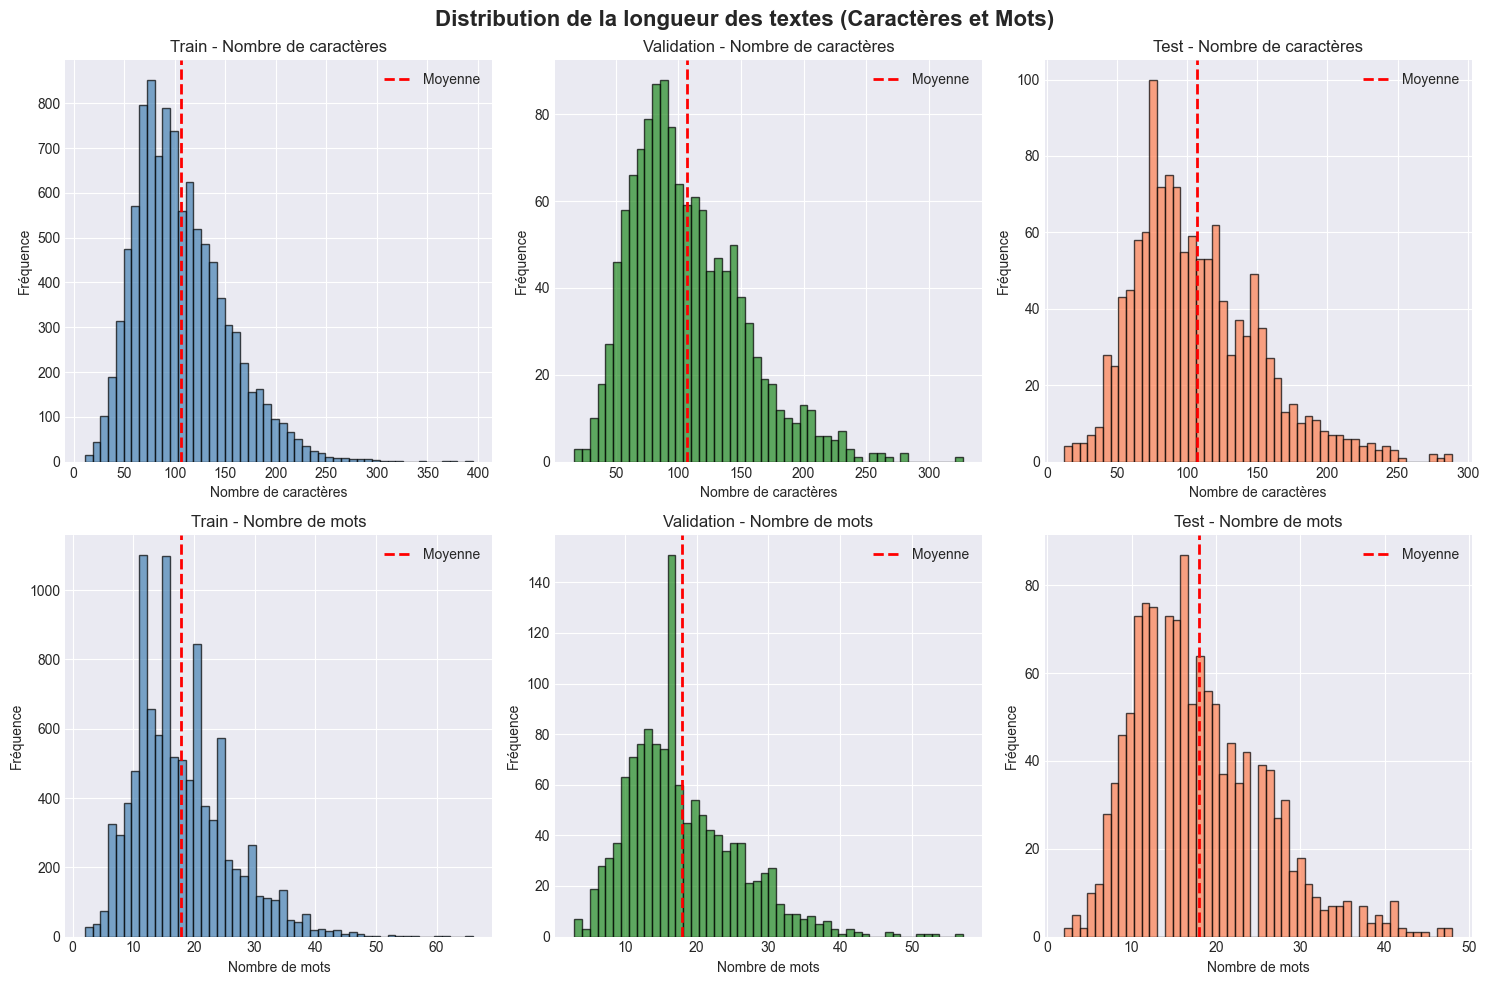


✓ Les distributions montrent une bonne diversité de longueurs de texte.


In [15]:
# Visualisation des distributions de longueur
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution de la longueur des textes (Caractères et Mots)', fontsize=16, fontweight='bold')

# Histogrammes pour les caractères
axes[0, 0].hist(df_train_tsv['char_count'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Train - Nombre de caractères')
axes[0, 0].set_xlabel('Nombre de caractères')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(df_train_tsv['char_count'].mean(), color='red', linestyle='--', linewidth=2, label='Moyenne')
axes[0, 0].legend()

axes[0, 1].hist(df_valid_tsv['char_count'], bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Validation - Nombre de caractères')
axes[0, 1].set_xlabel('Nombre de caractères')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].axvline(df_valid_tsv['char_count'].mean(), color='red', linestyle='--', linewidth=2, label='Moyenne')
axes[0, 1].legend()

axes[0, 2].hist(df_test_tsv['char_count'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Test - Nombre de caractères')
axes[0, 2].set_xlabel('Nombre de caractères')
axes[0, 2].set_ylabel('Fréquence')
axes[0, 2].axvline(df_test_tsv['char_count'].mean(), color='red', linestyle='--', linewidth=2, label='Moyenne')
axes[0, 2].legend()

# Histogrammes pour les mots
axes[1, 0].hist(df_train_tsv['word_count'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Train - Nombre de mots')
axes[1, 0].set_xlabel('Nombre de mots')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].axvline(df_train_tsv['word_count'].mean(), color='red', linestyle='--', linewidth=2, label='Moyenne')
axes[1, 0].legend()

axes[1, 1].hist(df_valid_tsv['word_count'], bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Validation - Nombre de mots')
axes[1, 1].set_xlabel('Nombre de mots')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].axvline(df_valid_tsv['word_count'].mean(), color='red', linestyle='--', linewidth=2, label='Moyenne')
axes[1, 1].legend()

axes[1, 2].hist(df_test_tsv['word_count'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1, 2].set_title('Test - Nombre de mots')
axes[1, 2].set_xlabel('Nombre de mots')
axes[1, 2].set_ylabel('Fréquence')
axes[1, 2].axvline(df_test_tsv['word_count'].mean(), color='red', linestyle='--', linewidth=2, label='Moyenne')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\n✓ Les distributions montrent une bonne diversité de longueurs de texte.")

# SECTION 4 : ANALYSE DU CONTENU DES TEXTES (NLP)

## 4.1 Analyse des mots les plus fréquents

In [16]:
print("\n" + "=" * 80)
print("ANALYSE DU CONTENU DES TEXTES (NLP)")
print("=" * 80)

# Récupérer les stop words anglais
stop_words = set(stopwords.words('english'))

def analyze_word_frequency(df, dataset_name, top_n=20):
    """Analyser la fréquence des mots"""
    print(f"\n{dataset_name}:")
    
    # Combiner tous les textes
    all_texts = ' '.join(df['text'].fillna('').astype(str))
    
    # Tokenization et nettoyage basique
    tokens = all_texts.lower().split()
    # Filtrer les tokens très courts
    tokens = [t for t in tokens if len(t) > 2]
    
    # Mots sans stop words
    tokens_no_stop = [t for t in tokens if t not in stop_words and t.isalpha()]
    word_freq_no_stop = Counter(tokens_no_stop)
    top_words_no_stop = word_freq_no_stop.most_common(top_n)
    
    print(f"\n  Top {top_n} mots (SANS stop words):")
    for i, (word, freq) in enumerate(top_words_no_stop[:10], 1):
        print(f"    {i}. {word}: {freq}")
    
    # Stop words les plus fréquents
    tokens_is_stop = [t for t in tokens if t in stop_words]
    stop_freq = Counter(tokens_is_stop)
    top_stops = stop_freq.most_common(10)
    
    print(f"\n  Stop words les plus fréquents:")
    for i, (word, freq) in enumerate(top_stops[:5], 1):
        print(f"    {i}. {word}: {freq}")
    
    return word_freq_no_stop, top_words_no_stop

word_freq_no_stop_train, top_words_train = analyze_word_frequency(df_train_tsv, "Train")
word_freq_no_stop_valid, top_words_valid = analyze_word_frequency(df_valid_tsv, "Validation")
word_freq_no_stop_test, top_words_test = analyze_word_frequency(df_test_tsv, "Test")


ANALYSE DU CONTENU DES TEXTES (NLP)

Train:

  Top 20 mots (SANS stop words):
    1. says: 2355
    2. percent: 965
    3. state: 684
    4. obama: 607
    5. tax: 596
    6. health: 574
    7. people: 542
    8. would: 527
    9. president: 510
    10. million: 459

  Stop words les plus fréquents:
    1. the: 9606
    2. and: 2778
    3. for: 2069
    4. that: 1799
    5. has: 1274

Validation:

  Top 20 mots (SANS stop words):
    1. says: 294
    2. percent: 112
    3. health: 96
    4. state: 86
    5. obama: 72
    6. care: 72
    7. new: 72
    8. president: 65
    9. would: 63
    10. tax: 62

  Stop words les plus fréquents:
    1. the: 1257
    2. and: 337
    3. for: 254
    4. that: 217
    5. has: 149

Test:

  Top 20 mots (SANS stop words):
    1. says: 306
    2. percent: 132
    3. state: 90
    4. tax: 78
    5. obama: 72
    6. president: 68
    7. health: 66
    8. people: 65
    9. million: 62
    10. federal: 59

  Stop words les plus fréquents:
    1. the: 1197
 

## 4.2 Détection de patterns spéciaux (URLs, emojis, caractères spéciaux)

In [17]:
print("\n" + "-" * 80)
print("DÉTECTION DE PATTERNS SPÉCIAUX")
print("-" * 80)

def detect_special_patterns(df, dataset_name):
    """Détecter les patterns spéciaux dans les textes"""
    print(f"\n{dataset_name}:")
    
    # Hashtags
    hashtags = df['text'].fillna('').str.contains(r'#\w+', regex=True).sum()
    print(f"  - Textes avec hashtags : {hashtags} ({hashtags/len(df)*100:.2f}%)")
    
    # Mentions (@username)
    mentions = df['text'].fillna('').str.contains(r'@\w+', regex=True).sum()
    print(f"  - Textes avec mentions : {mentions} ({mentions/len(df)*100:.2f}%)")
    
    # Nombres
    numbers = df['text'].fillna('').str.contains(r'\d+', regex=True).sum()
    print(f"  - Textes contenant des nombres : {numbers} ({numbers/len(df)*100:.2f}%)")
    
    # Ponctuation excessive
    excessive_punct = df['text'].fillna('').str.contains(r'[!?.]{2,}', regex=True).sum()
    print(f"  - Textes avec ponctuation excessive (!!!???) : {excessive_punct} ({excessive_punct/len(df)*100:.2f}%)")
    
    # MAJUSCULES excessives
    uppercase_ratio = df['text'].fillna('').apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
    high_uppercase = (uppercase_ratio > 0.5).sum()
    print(f"  - Textes avec majorité en MAJUSCULES : {high_uppercase} ({high_uppercase/len(df)*100:.2f}%)")

detect_special_patterns(df_train_tsv, "Train")
detect_special_patterns(df_valid_tsv, "Validation")
detect_special_patterns(df_test_tsv, "Test")


--------------------------------------------------------------------------------
DÉTECTION DE PATTERNS SPÉCIAUX
--------------------------------------------------------------------------------

Train:
  - Textes avec hashtags : 24 (0.23%)
  - Textes avec mentions : 9 (0.09%)
  - Textes contenant des nombres : 4024 (39.19%)
  - Textes avec ponctuation excessive (!!!???) : 357 (3.48%)
  - Textes avec majorité en MAJUSCULES : 1 (0.01%)

Validation:
  - Textes avec hashtags : 2 (0.16%)
  - Textes avec mentions : 0 (0.00%)
  - Textes contenant des nombres : 508 (39.56%)
  - Textes avec ponctuation excessive (!!!???) : 46 (3.58%)
  - Textes avec majorité en MAJUSCULES : 2 (0.16%)

Test:
  - Textes avec hashtags : 2 (0.16%)
  - Textes avec mentions : 0 (0.00%)
  - Textes contenant des nombres : 509 (39.67%)
  - Textes avec ponctuation excessive (!!!???) : 63 (4.91%)
  - Textes avec majorité en MAJUSCULES : 0 (0.00%)


## 4.3 Taille du vocabulaire et diversité linguistique

In [18]:
print("\n" + "-" * 80)
print("DIVERSITÉ LINGUISTIQUE")
print("-" * 80)

def analyze_vocabulary(df, dataset_name):
    """Analyser le vocabulaire"""
    print(f"\n{dataset_name}:")
    
    # Combiner tous les textes
    all_texts = ' '.join(df['text'].fillna('').astype(str))
    tokens = all_texts.lower().split()
    tokens = [t for t in tokens if len(t) > 0]
    
    # Vocabulaire unique
    unique_tokens = len(set(tokens))
    total_tokens = len(tokens)
    vocab_diversity = unique_tokens / total_tokens if total_tokens > 0 else 0
    
    print(f"  - Nombre total de tokens : {total_tokens:,}")
    print(f"  - Nombre de tokens uniques : {unique_tokens:,}")
    print(f"  - Type-Token Ratio (TTR) : {vocab_diversity:.4f}")
    print(f"    (Ratio proche de 1 = vocabulaire très divers, proche de 0 = vocabulaire limité)")

analyze_vocabulary(df_train_tsv, "Train")
analyze_vocabulary(df_valid_tsv, "Validation")
analyze_vocabulary(df_test_tsv, "Test")


--------------------------------------------------------------------------------
DIVERSITÉ LINGUISTIQUE
--------------------------------------------------------------------------------

Train:
  - Nombre total de tokens : 183,882
  - Nombre de tokens uniques : 20,348
  - Type-Token Ratio (TTR) : 0.1107
    (Ratio proche de 1 = vocabulaire très divers, proche de 0 = vocabulaire limité)

Validation:
  - Nombre total de tokens : 23,017
  - Nombre de tokens uniques : 5,788
  - Type-Token Ratio (TTR) : 0.2515
    (Ratio proche de 1 = vocabulaire très divers, proche de 0 = vocabulaire limité)

Test:
  - Nombre total de tokens : 23,054
  - Nombre de tokens uniques : 5,734
  - Type-Token Ratio (TTR) : 0.2487
    (Ratio proche de 1 = vocabulaire très divers, proche de 0 = vocabulaire limité)


# SECTION 5 : ANALYSE DE LA DISTRIBUTION DES LABELS

## 5.1 Distribution des classes

In [19]:
print("\n" + "=" * 80)
print("ANALYSE DE LA DISTRIBUTION DES LABELS")
print("=" * 80)

def analyze_label_distribution(df, dataset_name):
    """Analyser la distribution des labels"""
    print(f"\n{dataset_name}:")
    
    label_counts = df['label'].value_counts()
    label_percent = (df['label'].value_counts() / len(df) * 100).round(2)
    
    label_summary = pd.DataFrame({
        'Label': label_counts.index,
        'Nombre': label_counts.values,
        'Pourcentage': label_percent.values
    })
    
    print(label_summary.to_string(index=False))
    
    # Ratio de déséquilibre
    max_class = label_counts.max()
    min_class = label_counts.min()
    imbalance_ratio = max_class / min_class if min_class > 0 else float('inf')
    print(f"\n  Ratio de déséquilibre (max/min) : {imbalance_ratio:.2f}")
    
    if imbalance_ratio > 2:
        print("  ⚠️  Données fortement déséquilibrées - attention requise pour la modélisation")
    else:
        print("  ✓ Données relativement équilibrées")
    
    return label_summary

train_labels = analyze_label_distribution(df_train_tsv, "Train")
valid_labels = analyze_label_distribution(df_valid_tsv, "Validation")
test_labels = analyze_label_distribution(df_test_tsv, "Test")


ANALYSE DE LA DISTRIBUTION DES LABELS

Train:
      Label  Nombre  Pourcentage
  half-true    2123        20.67
      false    1998        19.46
mostly-true    1966        19.14
       true    1683        16.39
barely-true    1657        16.14
 pants-fire     842         8.20

  Ratio de déséquilibre (max/min) : 2.52
  ⚠️  Données fortement déséquilibrées - attention requise pour la modélisation

Validation:
      Label  Nombre  Pourcentage
      false     263        20.48
mostly-true     251        19.55
  half-true     248        19.31
barely-true     237        18.46
       true     169        13.16
 pants-fire     116         9.03

  Ratio de déséquilibre (max/min) : 2.27
  ⚠️  Données fortement déséquilibrées - attention requise pour la modélisation

Test:
      Label  Nombre  Pourcentage
  half-true     267        20.81
      false     250        19.49
mostly-true     249        19.41
barely-true     214        16.68
       true     211        16.45
 pants-fire      92         7

## 5.2 Visualisation de la distribution des labels

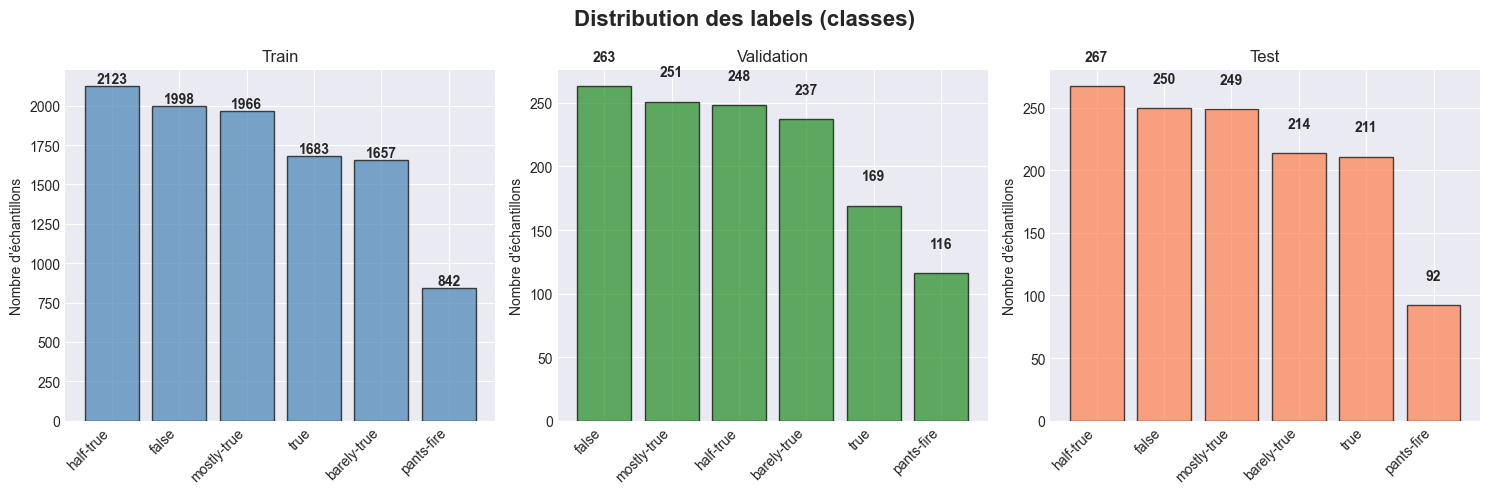

In [20]:
# Visualisation des distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribution des labels (classes)', fontsize=16, fontweight='bold')

# Train
train_counts = df_train_tsv['label'].value_counts()
axes[0].bar(range(len(train_counts)), train_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(train_counts)))
axes[0].set_xticklabels(train_counts.index, rotation=45, ha='right')
axes[0].set_title('Train')
axes[0].set_ylabel('Nombre d\'échantillons')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Validation
valid_counts = df_valid_tsv['label'].value_counts()
axes[1].bar(range(len(valid_counts)), valid_counts.values, color='forestgreen', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(valid_counts)))
axes[1].set_xticklabels(valid_counts.index, rotation=45, ha='right')
axes[1].set_title('Validation')
axes[1].set_ylabel('Nombre d\'échantillons')
for i, v in enumerate(valid_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Test
test_counts = df_test_tsv['label'].value_counts()
axes[2].bar(range(len(test_counts)), test_counts.values, color='coral', alpha=0.7, edgecolor='black')
axes[2].set_xticks(range(len(test_counts)))
axes[2].set_xticklabels(test_counts.index, rotation=45, ha='right')
axes[2].set_title('Test')
axes[2].set_ylabel('Nombre d\'échantillons')
for i, v in enumerate(test_counts.values):
    axes[2].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()